# fernmetastasen

In [1]:
import os
from pathlib import Path
import pandas as pd
import duckdb as ddb
from connection_helper import sql
import numpy as np
from pandas_plots import tbl, pls, hlp
import datetime as dt

hlp.show_package_version(["pygwalker"])
os.environ["RENDERER"] = "svg"
os.environ['THEME']='light'

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

file_db_clin = dir_db/'2025-11-11_data_clin.duckdb'

if not file_db_clin.exists():
    raise(FileNotFoundError(f"File {file_db_clin} not found"))

🐍 3.12.8 | 📦 pygwalker: 0.4.9.15 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.1 | 📦 pandas-plots: 0.21.2 | 📦 connection-helper: 0.13.1


In [2]:
con = ddb.connect(file_db_clin.as_posix(), read_only=True)
_=con.execute("PRAGMA disable_progress_bar;")
# _=con.execute(f"ATTACH DATABASE '{file_db_clin}' as clin; SET SCHEMA 'clin';")

In [3]:
# con.sql("show table Diagnose_Fernmetastase")

## dataset
- filter
  - `z_dy` 2020-2022
- metrics
  - tum, pat, fm

In [4]:
db_fm = (con.sql("""--sql
            select 
                name as fm_localisation,
                t.z_tum_id,
                t.z_pat_id,
                z_kkr_label,
                z_dy,
                z_icd10_3d,
                z_m_pc_1,
                M_p,
                fm.FernmetastaseId,
            from Diagnose_Fernmetastase fm 
            right join Tumor t on fm.z_tum_id = t.oBDS_RKIPatientTumorId
            left join dim_fm_lokalisation on fm.Lokalisation = dim_fm_lokalisation.code
            -- where z_m_pc_1 = '1'
            --and left(Diagnose_ICD10_Code,3) = 'C73' 
            and ifnull(z_dy,0) between 2020 and 2022
            """)
    # .to_df()
)
cnt_tum = db_fm.count("distinct z_tum_id").fetchone()[0]
cnt_pat = db_fm.count("distinct z_pat_id").fetchone()[0]
cnt_fm = db_fm.count("distinct FernmetastaseId").fetchone()[0]

print(f"Anzahl Patienten: {cnt_pat:_}")
print(f"Anzahl Tumoren: {cnt_tum:_}")
print(f"Anzahl FM: {cnt_fm:_}")
tbl.descr_db(db_fm, "fm-items,M1,2020-2022")

Anzahl Patienten: 2_735_152
Anzahl Tumoren: 3_241_401
Anzahl FM: 490_363
🗄️ fm-items,M1,2020-2022	3_420_093, 9
	("fm_localisation, z_tum_id, z_pat_id, z_kkr_label, z_dy, z_icd10_3d, z_m_pc_1, M_p, FernmetastaseId")
┌─────────────────┬──────────────────────┬──────────────────────┬─────────────┬───────┬────────────┬──────────┬─────────┬───────────────────────┐
│ fm_localisation │       z_tum_id       │       z_pat_id       │ z_kkr_label │ z_dy  │ z_icd10_3d │ z_m_pc_1 │   M_p   │    FernmetastaseId    │
│     varchar     │       varchar        │       varchar        │   varchar   │ int16 │  varchar   │ varchar  │ varchar │        varchar        │
├─────────────────┼──────────────────────┼──────────────────────┼─────────────┼───────┼────────────┼──────────┼─────────┼───────────────────────┤
│ Knochen         │ 0e7ba901-8512-4346…  │ 8f5caf75-376e-4044…  │ 09-BY       │  2022 │ C61        │ 1        │ NULL    │ 8f186640-b9af-455a-…  │
│ Knochen         │ 217996f8-225c-4467…  │ acd8bf72-ffb

## 🕹️ interactive

In [5]:
if False:
    import pygwalker as pyg

    spec="config/pygwalker_spec_fm.json"
    hlp.add_measures_to_pyg_config(spec, nodes=[
        ("cnt_tum", "count(distinct z_tum_id)"),
        ("cnt_pat", "count(distinct z_pat_id)"),
        ("cnt_fm", "count(distinct FernmetastaseId)"),
        ])

    _=pyg.walk(db_fm.to_df(), kernel_computation=True, spec=spec)

## M1 vs has_fm
- `M1`: either M_c or M_p
- `has_fm`: any FM is assigned to tumor?

In [6]:
db_fm_m1 = con.sql("""--sql
    select
        z_tum_id
        ,first(z_kkr_label) as z_kkr_label
        ,max(z_m_pc_1) as z_m_pc_1
        ,max((FernmetastaseId is not null)) as has_fm
    from db_fm
    group by z_tum_id
""")

# tbl.descr_db(db_fm_m1)

### share of M1 in all tumors
- 10% of all tumors have `M1` (273k)

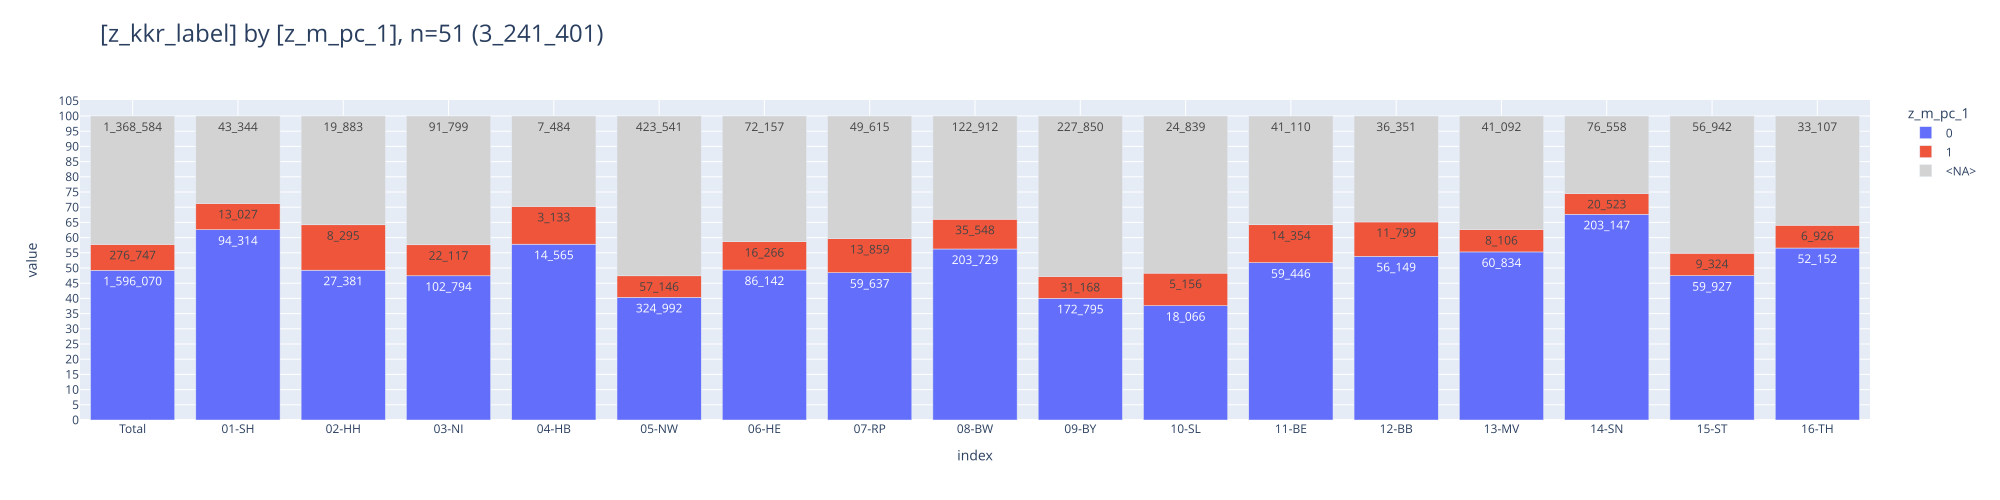

In [7]:
_=pls.plot_stacked_bars(db_fm_m1.project("z_kkr_label, z_m_pc_1").to_df(), show_total=True, relative=True, normalize=True)

### share of has_fm in M1
- 10% of `M1` have no FM assigned

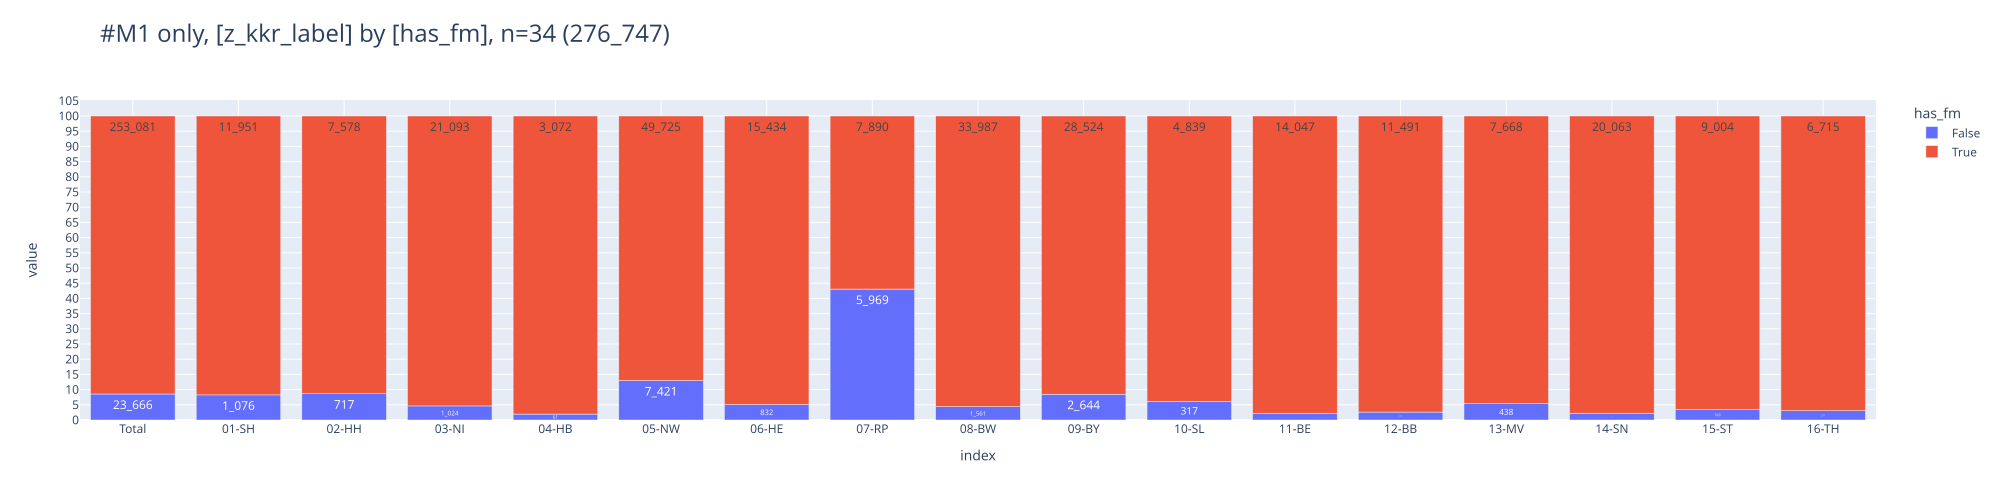

In [8]:
_=pls.plot_stacked_bars(db_fm_m1.filter("z_m_pc_1 = '1'").project("z_kkr_label, has_fm").to_df(), show_total=True, relative=True, normalize=True, caption="M1 only")

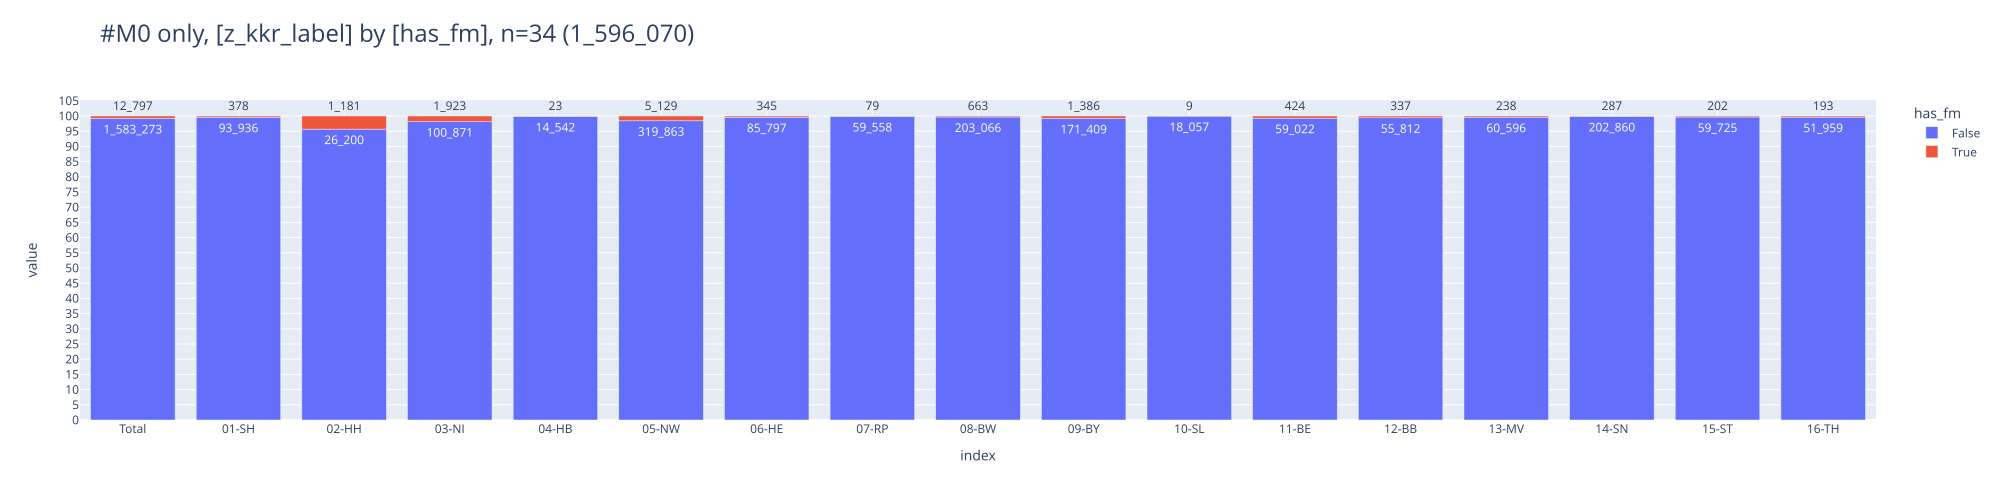

In [9]:
_=pls.plot_stacked_bars(db_fm_m1.filter("z_m_pc_1 = '0'").project("z_kkr_label, has_fm").to_df(), show_total=True, relative=True, normalize=True, caption="M0 only")